6. Türkçe isim listenle aynı WaveNet'i eğit. Ürettiği isimlerden örnek ver, dev loss'u hafta 4'ün Türkçe MLP'siyle karşılaştır. Türkçe'de bağlamı 8'e çıkarmak ne kazandırdı, yaz.


In [1]:

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
words = open('turkce_isimler.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

13872
14
['aba', 'abaca', 'abacan', 'abaç', 'abay', 'abayhan', 'abaza', 'abbas']


In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'w', 23: 'x', 24: 'y', 25: 'z', 26: 'ç', 27: 'ö', 28: 'ü', 29: 'ğ', 30: 'ı', 31: 'ş', 0: '.'}
32


In [4]:
import random
random.seed(42)
random.shuffle(words)

In [5]:
block_size = 8 

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([80060, 8]) torch.Size([80060])
torch.Size([9906, 8]) torch.Size([9906])
torch.Size([9965, 8]) torch.Size([9965])


In [6]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> g
.......g --> ü
......gü --> n
.....gün --> d
....günd --> ü
...gündü --> z
..gündüz --> .
........ --> s
.......s --> e
......se --> b
.....seb --> a
....seba --> t
...sebat --> .
........ --> g
.......g --> ö
......gö --> k
.....gök --> h
....gökh --> u
...gökhu --> n
..gökhun --> .


In [7]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

In [8]:
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters 
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers 
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # forward pass
    if self.training:
      
      if x.ndim==2:
        dim=0
      elif x.ndim == 3:
        dim=(0,1)
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

In [9]:
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [10]:
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

In [11]:
class FlattenConsecutive:
  def __init__(self,n):
    self.n=n
  def __call__(self, x):
    B,T,C = x.shape
    x = x.view(B,T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []


In [12]:
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [13]:
torch.manual_seed(42)
n_embd = 24
n_hidden = 128

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

77344


In [14]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 27, 11],
        [ 0, 16,  5, 17,  9, 31,  1, 14],
        [ 0,  0,  0,  0,  0,  0,  0, 17]])

In [15]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 32)


In [16]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 3.4534
  10000/ 200000: 1.7804
  20000/ 200000: 1.9932
  30000/ 200000: 2.1080
  40000/ 200000: 2.2508
  50000/ 200000: 1.6312
  60000/ 200000: 1.6866
  70000/ 200000: 1.6421
  80000/ 200000: 1.8521
  90000/ 200000: 1.7808
 100000/ 200000: 1.9871
 110000/ 200000: 1.6700
 120000/ 200000: 1.6689
 130000/ 200000: 1.4425
 140000/ 200000: 1.5185
 150000/ 200000: 1.7877
 160000/ 200000: 1.2652
 170000/ 200000: 1.3999
 180000/ 200000: 1.8301
 190000/ 200000: 1.5575


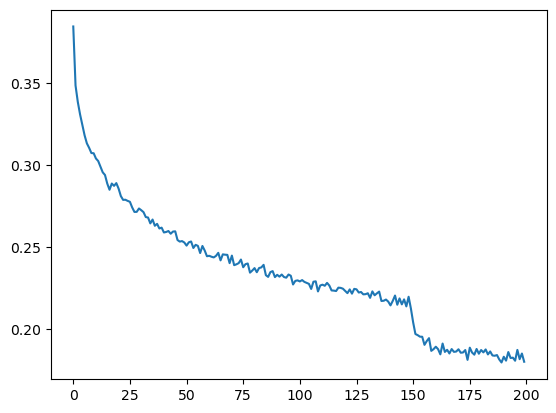

In [17]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [18]:

for layer in model.layers:
  layer.training = False

In [19]:
# evaluate the loss
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.4845106601715088
val 2.1261916160583496


In [20]:
for _ in range(20):
    
    out = []
    context = [0] * block_size
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

berlibas.
yabar.
acunalan.
andarsan.
zihniye.
nezahat.
başkaya.
yafel.
ümithan.
sitdika.
ruhbat.
şehzan.
gülamin.
karahan.
nevaldır.
acarsdır.
ahatin.
kızıltuz.
asra.
suüdyet.



####  Hafta 4 Türkçe MLP ile Karşılaştırma

| Model | Bağlam (Context) | Parametre Sayısı | Dev Loss |
| :--- | :---: | :---: | :---: |
| Hafta 4 Türkçe Düz MLP | 3 | ~12.500 | ~2.28 |
| Hafta 6 Türkçe WaveNet | 8 | 77.344 | **2.1262** |

Hafta 4'teki 3 harflik bağlama sahip düz MLP modelinde dev loss yaklaşık **2.28** bandındaydı. WaveNet mimarisi ve 8 harflik bağlam ile dev loss **2.1262** seviyesine kadar düşürülerek yaklaşık **0.15** puanlık net bir başarı artışı elde edilmiştir.
